In [2]:
### using tensorboard

import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras.datasets import mnist
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [4]:
print(len(X_train))
print(len(X_test))

60000
10000


0


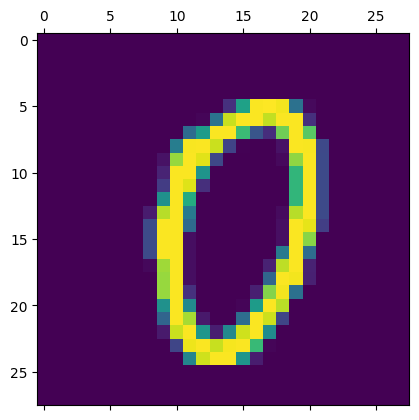

In [5]:
plt.matshow(X_train[1000])
print(y_train[1000])

In [6]:
X_train[0].shape

(28, 28)

In [7]:
### flattening the feature vector

X_train = X_train / 255
X_test = X_test / 255

In [8]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

print(X_train_flattened.shape)
print(X_test_flattened.shape)

(60000, 784)
(10000, 784)


In [9]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

tb_callback = tf.keras.callbacks.TensorBoard(log_dir='logs/', histogram_freq=1)

model.fit(X_train, y_train, epochs=10, callbacks=[tb_callback])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9234 - loss: 0.2702
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9638 - loss: 0.1230
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9732 - loss: 0.0881
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9790 - loss: 0.0673
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9834 - loss: 0.0540
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9872 - loss: 0.0422
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9885 - loss: 0.0363
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9911 - loss: 0.0294
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9922 - loss: 0.0245
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9934 - loss: 0.0214


In [11]:
model.get_weights()

[array([[-0.01334322,  0.01936102, -0.04397669, ..., -0.02035409,
          0.03228512, -0.03934291],
        [ 0.08052991,  0.05428462, -0.0388879 , ...,  0.039209  ,
          0.05195005,  0.01964106],
        [-0.0075413 ,  0.02899504,  0.06008492, ..., -0.07179838,
          0.03038297, -0.0714424 ],
        ...,
        [-0.06553096, -0.03033765,  0.02929768, ...,  0.00271435,
          0.02628237,  0.006193  ],
        [-0.04896671, -0.03762718,  0.07899661, ...,  0.0759867 ,
          0.02134474, -0.00866777],
        [ 0.00047619,  0.05910979,  0.0728392 , ..., -0.07228291,
          0.04675297,  0.03382666]], shape=(784, 100), dtype=float32),
 array([ 0.13146259, -0.12526846,  0.02495604,  0.11428694, -0.13394827,
         0.02113321, -0.01432987,  0.23863254,  0.20207736,  0.07778   ,
        -0.15232204, -0.06761122,  0.1819187 ,  0.1194033 ,  0.03745499,
        -0.11815883,  0.24992299,  0.21366355, -0.12983297,  0.20955501,
        -0.18024804, -0.2219903 ,  0.17405228, -

In [19]:
# to load tensorboard

#load_ext tensorboard
%reload_ext tensorboard
%tensorboard --logdir logs/train/

Reusing TensorBoard on port 6007 (pid 26340), started 0:03:03 ago. (Use '!kill 26340' to kill it.)